In [2]:
using Pkg
Pkg.activate("..")
using Distributed
using ClusterManagers
using Eliashberg
using GLMakie
println("Eliashberg loaded successfully!")

  Activating 

Eliashberg loaded successfully!


project at `~/Developer/theory/Eliashberg`


## 1D Tight-Binding model 

In [5]:
lattice= ChainLattice(1.5) # 晶格常数 1.5 的一维链
kgrid = generate_reciprocal_lattice(lattice, 2000)

tb = TightBinding(lattice, 1.0, -0.3)

TightBinding{1}(ChainLattice(1.5, [1.5;;]), Tuple{StaticArraysCore.SVector{1, Int64}, Float64}[([1], -1.0)], -0.3)

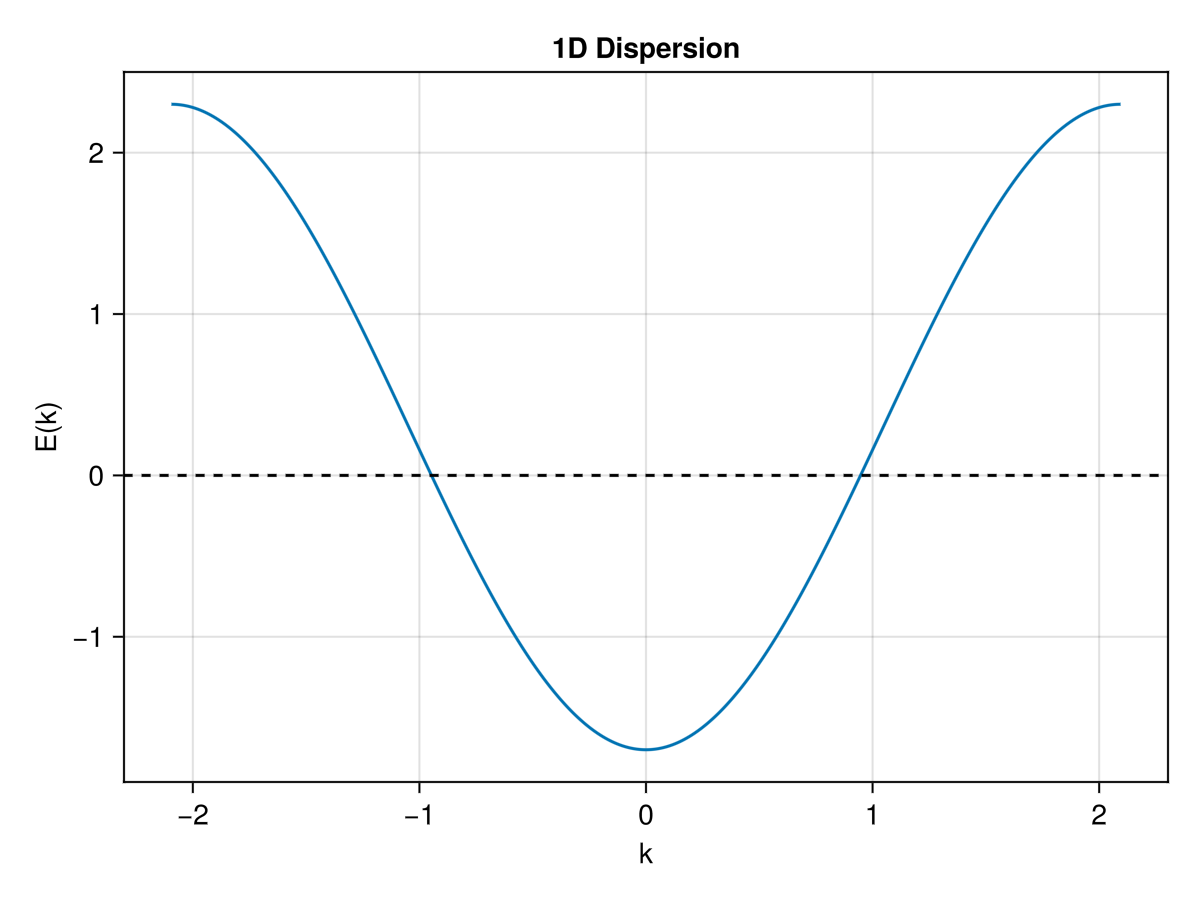

In [6]:
f = visualize_dispersion(tb, kgrid)
save("tb_1d_eband.png", f)
f

### Coulomb interaction

In [ ]:
interaction = ConstantInteraction(-2.5)
sc_field = BCSReducedPairing(:s_wave)

BareCoulombInteraction(0.001)

In [ ]:
# 另外，如果你想看纯局域的 Hubbard 排斥 (U > 0) 产生的“零声”模式，可以取消下面这行的注释：
# V_hubbard = ConstantInteraction(3.0) 

# 3. 极其优雅：依然复用 RPA 扫描器！
# 内部计算 V(q) 时，会自动派发到 1/q^2 (BareCoulomb) 或 常数 U (Hubbard)
matrix_plasmon = visualize_collective_modes(
    T_val=0.01, 
    model, 
    V_coulomb, # <--- 只需在这里把吸引势换成排斥势
    kgrid, 
    qpath, 
    omegas; 
    eta=0.02
)

# 4. 可视化
fig_plasmon = visualize_spectral_function(qpath, omegas, matrix_plasmon)
display(fig_plasmon)


LoadError: UndefVarError: `scan_rpa_spectral_function_hpc` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

🚀 开始扫描温度相图...
✅ 扫描完成！


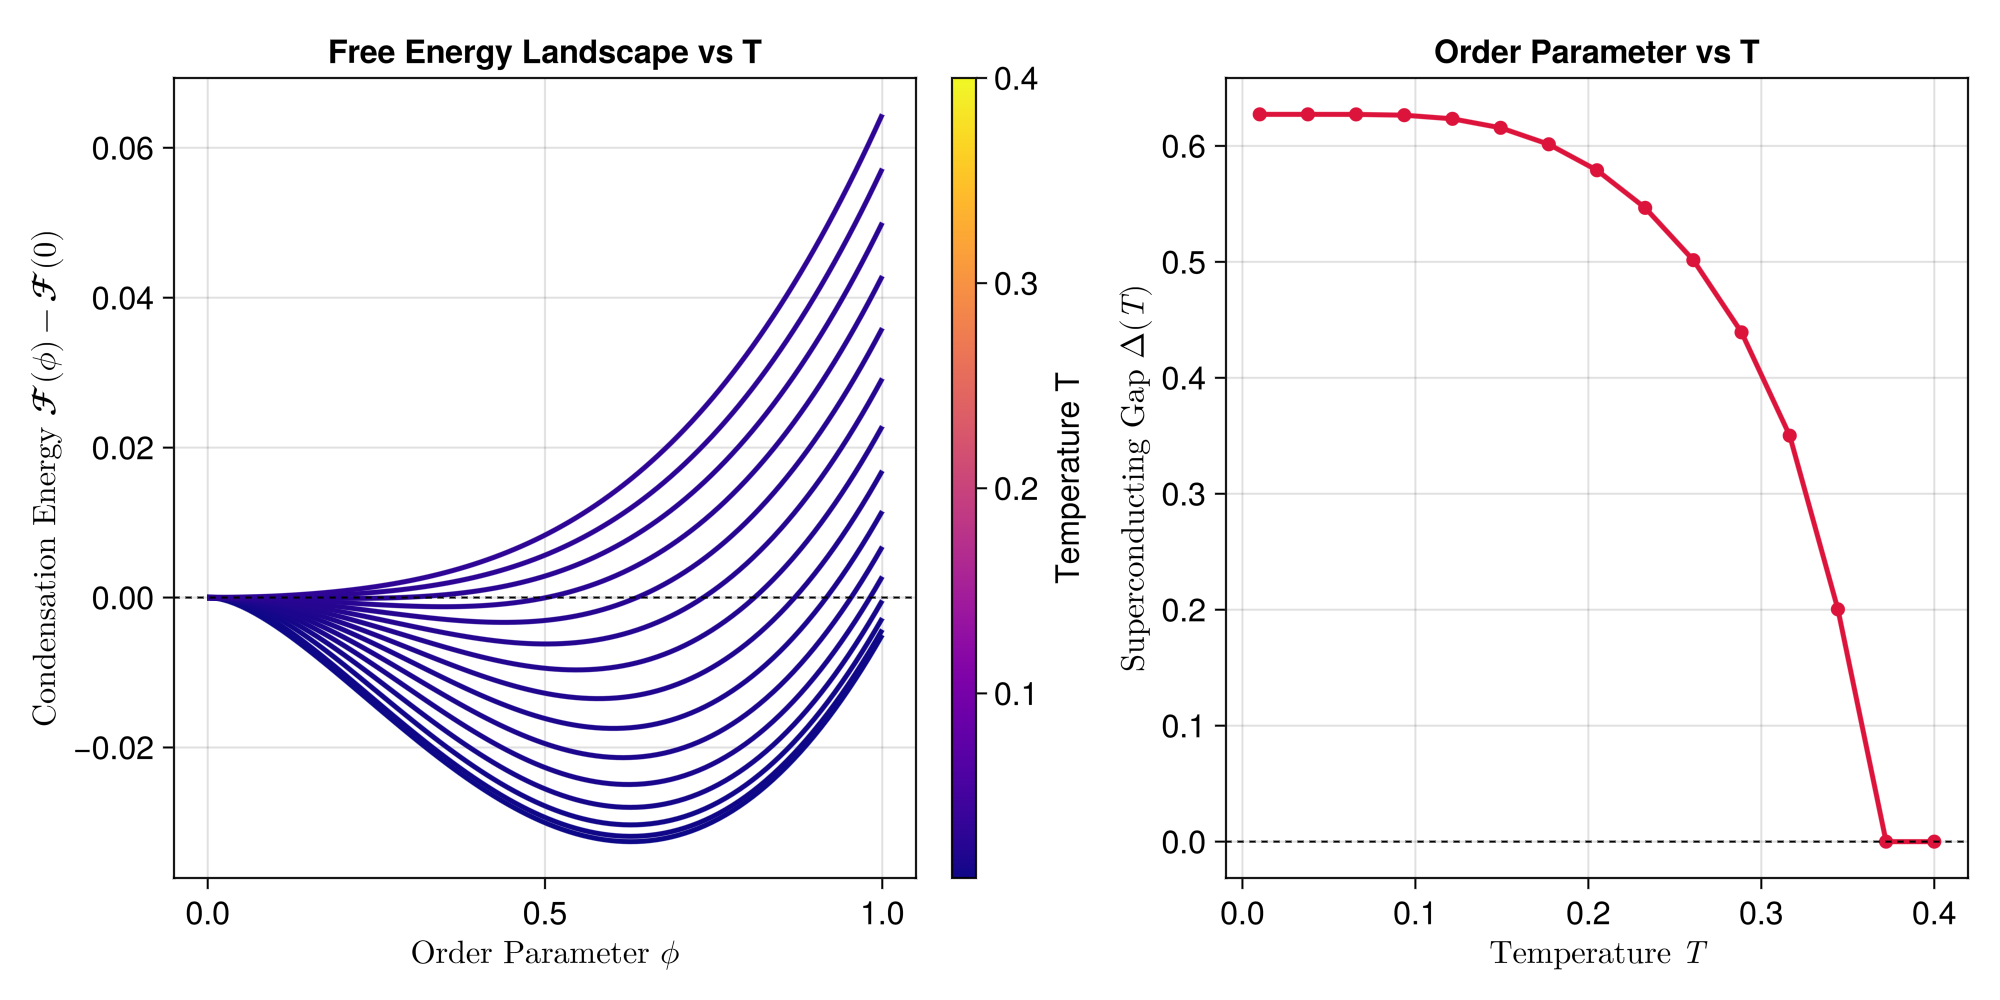

In [ ]:
visualize_phase_transition(phis, Ts,  sc_field, tb, interaction, kgrid, )

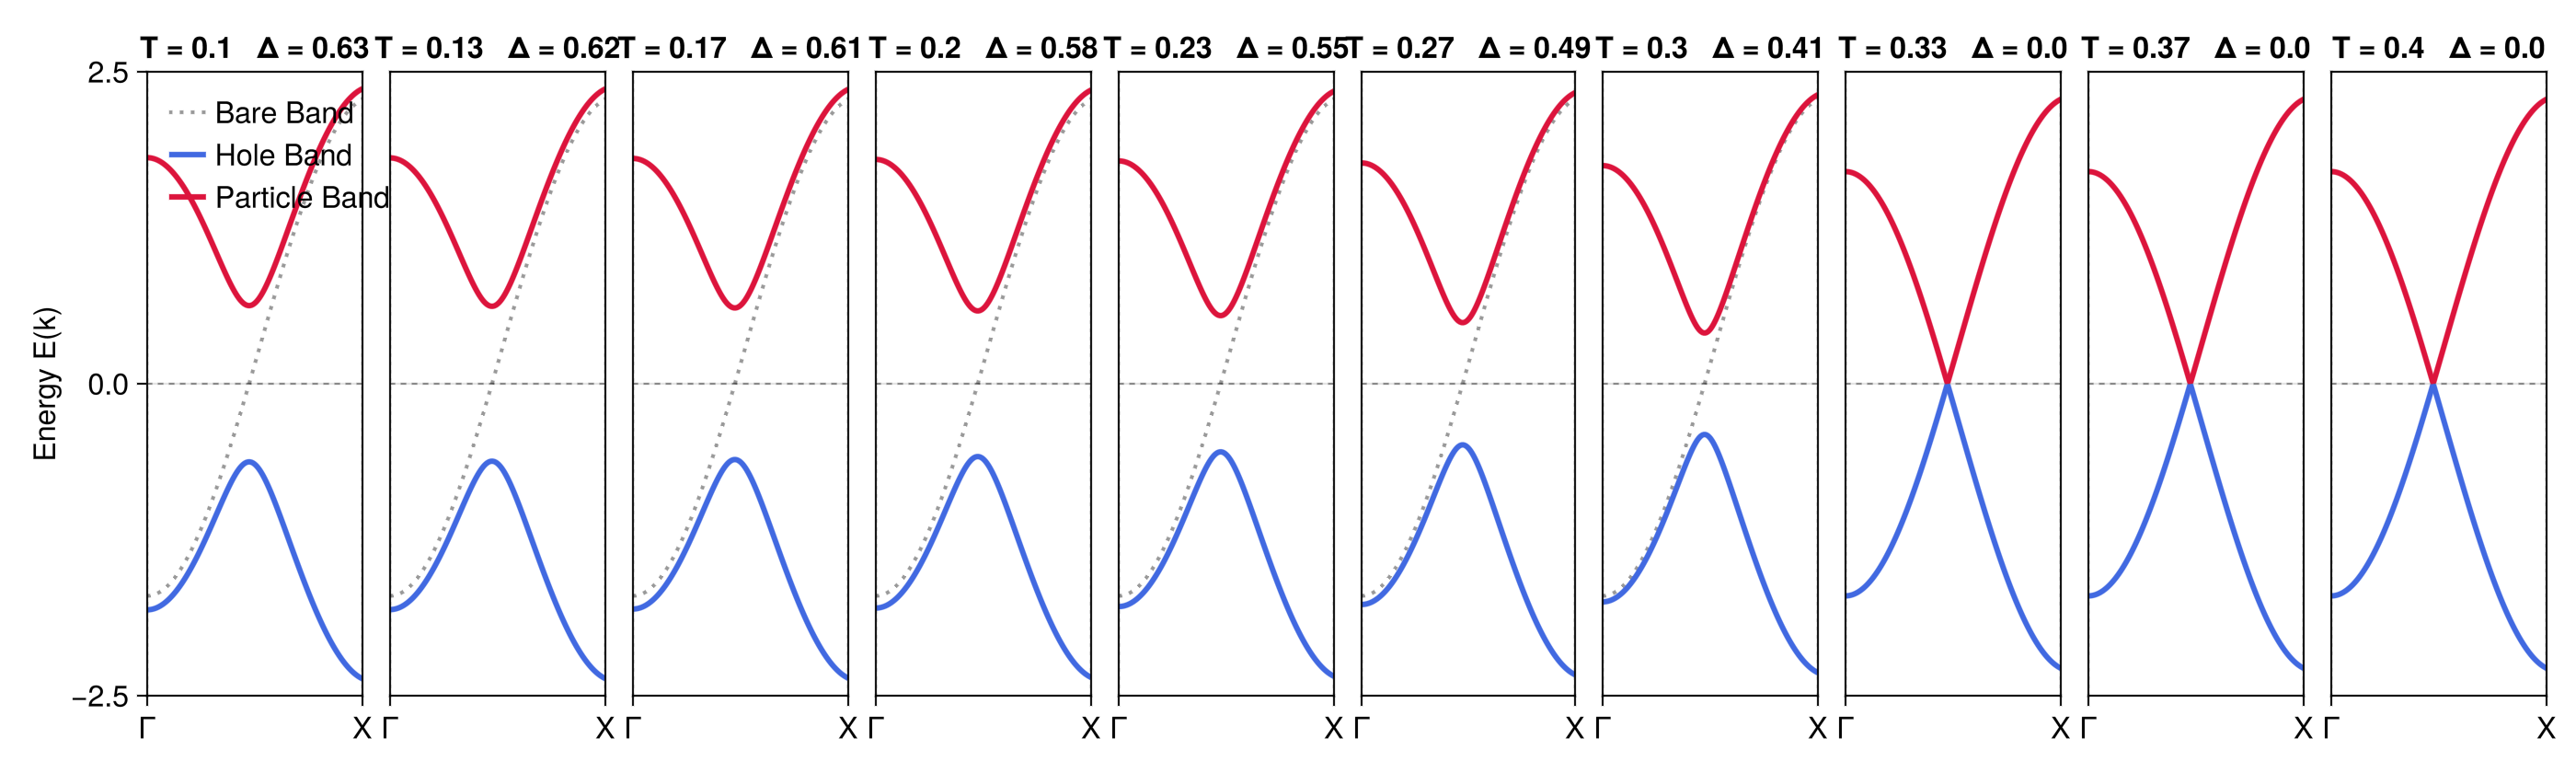

In [ ]:
visualize_renormalized_bands(Ts,  sc_field, tb, interaction, kgrid, kpath)

⏳ 正在求解基态能隙 (T = 0.1)...
✅ 基态能隙求得: Δ₀ = 0.6261
🚀 开始扫描超导集体激发谱 (q, ω)... 这可能需要一点时间


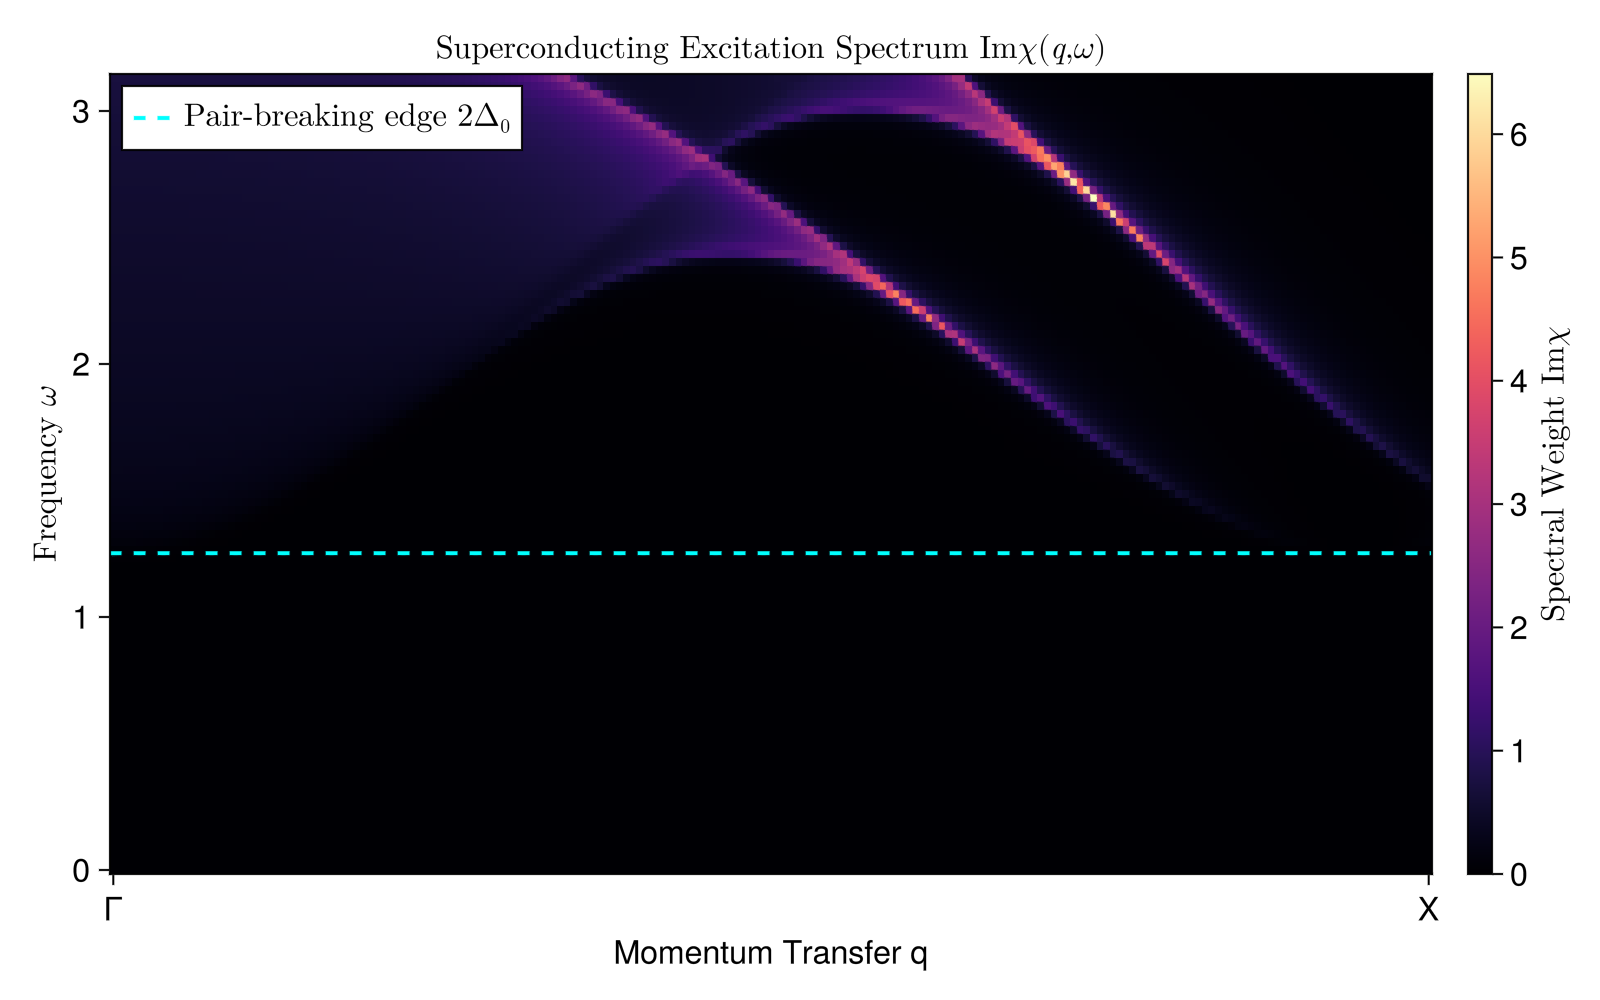

In [ ]:
T_val = 0.1
visualize_collective_modes(T_val, sc_field, tb, interaction, kgrid, kpath; eta=0.015)

### FFLO Pairing

🚀 开始扫描 FFLO 质心动量 q ... (h = 0.5)


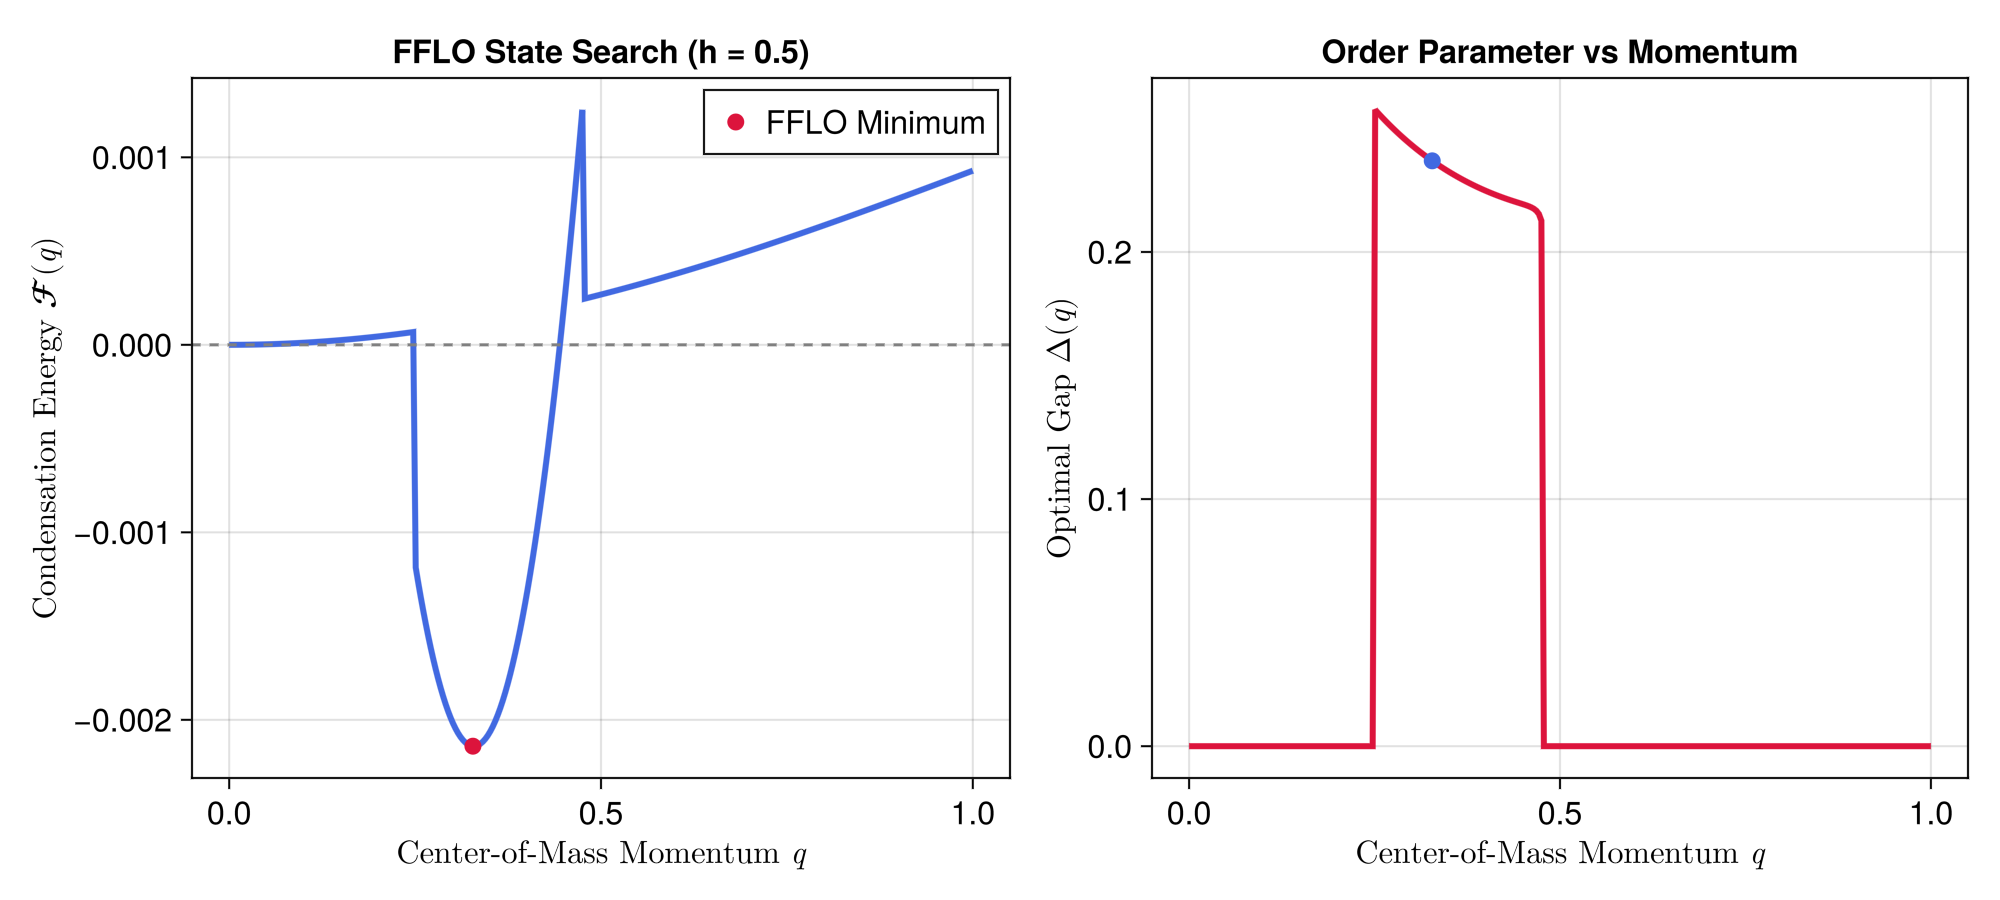

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

# 设定环境参数
T_val = 0.01
h_val = 0.5 # 施加一个 Zeeman 磁场 (注意：h 必须小于裸能隙，但在 Pauli 极限附近)

# 2. 设定我们要扫描的 q 范围 (沿着 qx 方向)
q_vals = range(0.0, 1.0, length=300) # 扫描 0 到 1.0 的动量

visualize_zeeman_pairing_landscape(T_val, h_val, q_vals, tb, interaction, kgrid)